# Gold-YOLO VisDrone Pipeline (Kaggle)

**Run and forget:** attach your VisDrone dataset, enable **GPU T4 x2** and **Internet**, then **Run All**. Come back later and read cell outputs plus the downloadable zip.

### Before you start
1. **Add Data** → attach VisDrone with either:
   - **Raw:** `images/{train,val,test-dev}` + `annotations/{train,val,test-dev}` (e.g. zip with `Dataset1/` folder), or
   - **Pre-converted:** `images/`, `labels/`, `coco_annotations/` (from `visdrone2coco.py` on your machine).
2. **Settings** → Accelerator: **GPU T4 x2**. Internet: **On**.
3. **Run All** (or Save Version → Run). If discovery fails, read the printed `/kaggle/input` listing in the log.

### What this notebook does
1. Clone Gold-YOLO, install deps, patch DDP / PyTorch 2.6 checkpoints
2. Convert VisDrone → YOLO labels + COCO JSON under `/kaggle/working/VisDrone-DET`
3. Smoke test (1 epoch) → full fine-tune (50 epochs, auto-resume)
4. **Phase 1:** baseline eval on test-dev
5. **Phase 2:** SAHI sliced inference + COCO mAP
6. Zip `runs/` → `/kaggle/working/gold_yolo_visdrone_results.zip` (Output tab)

Scroll to the **final summary cell** for paths to weights, metrics JSON, and the results zip.

## 1. Check GPU
Must be **GPU T4 x2** (not TPU / None).

In [1]:
import os
import torch

!nvidia-smi
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  [{i}] {torch.cuda.get_device_name(i)}")
else:
    raise RuntimeError("No GPU — set Accelerator to GPU T4 x2 and restart the session.")

Thu Jun 11 09:05:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1b. Constants & GPU detection
Configuration constants, model size selection, and dynamic GPU detection.

In [2]:
import os
import torch

# --- Model config selection ---
MODEL_CONFIGS = {
    "n": "configs/gold_yolo-n.py",
    "s": "configs/gold_yolo-s.py",
    "m": "configs/gold_yolo-m.py",
    "l": "configs/gold_yolo-l.py",
}
MODEL_SIZE = os.environ.get("GOLD_YOLO_SIZE", "s")
assert MODEL_SIZE in MODEL_CONFIGS, f"Invalid GOLD_YOLO_SIZE='{MODEL_SIZE}'. Choose: {list(MODEL_CONFIGS)}"
CONF_FILE = MODEL_CONFIGS[MODEL_SIZE]
EXP_NAME = f"gold_yolo_visdrone_{MODEL_SIZE}"

# --- GPU detection ---
n_gpu = torch.cuda.device_count() if torch.cuda.is_available() else 0
USE_DDP = n_gpu > 1
DEVICES = ",".join(str(i) for i in range(n_gpu)) if n_gpu else "cpu"
BASE_BATCH = 16
TOTAL_BATCH = BASE_BATCH if n_gpu <= 1 else BASE_BATCH * n_gpu

# --- Dataset & other settings ---
WORKING_ROOT = "/kaggle/working/VisDrone-DET"
VISDRONE_ROOT = os.environ.get("VISDRONE_ROOT", None)  # Kaggle-specific short-circuit
MASTER_PORT = os.environ.get("MASTER_PORT", "29501")

print(f"MODEL_SIZE={MODEL_SIZE}, CONF_FILE={CONF_FILE}")
print(f"n_gpu={n_gpu}, USE_DDP={USE_DDP}, DEVICES={DEVICES}, TOTAL_BATCH={TOTAL_BATCH}")

MODEL_SIZE=s, CONF_FILE=configs/gold_yolo-s.py
n_gpu=2, USE_DDP=True, DEVICES=0,1, TOTAL_BATCH=32


## 2. Environment setup
Clone into `/kaggle/working` (writable) and install dependencies.

In [3]:
import os
import subprocess, sys
from pathlib import Path

# Kill any lingering training processes from previous runs
!pkill -9 -f train.py || true
!pkill -9 -f torchrun || true

%cd /kaggle/working

!git clone https://github.com/huawei-noah/Efficient-Computing.git || true
%cd Efficient-Computing/Detection/Gold-YOLO

REPO_ROOT = "/kaggle/working/Efficient-Computing/Detection/Gold-YOLO"
os.chdir(REPO_ROOT)

# Writable dataset cache (avoids read-only errors on /kaggle/input)
!sed -i 's/osp.dirname(img_dir), "." + osp.basename(img_dir) + ".json"/"\/kaggle\/working", "." + osp.basename(img_dir) + ".json"/g' yolov6/data/datasets.py

# Strip torch, torchvision, and mmcv from requirements.txt to prevent pip from modifying them
req_file = Path("requirements.txt")
if req_file.is_file():
    lines = req_file.read_text(encoding="utf-8").splitlines()
    filtered_lines = [l for l in lines if not any(x in l for x in ("torch", "torchvision", "mmcv"))]
    req_file.write_text("\n".join(filtered_lines) + "\n", encoding="utf-8")
    print("Filtered requirements.txt:")
    print(req_file.read_text(encoding="utf-8"))

# Install core deps
!pip install -q -r requirements.txt || true
!pip install -q addict pycocotools sahi tqdm pillow pyyaml

print("Setup done. REPO_ROOT =", REPO_ROOT)

/kaggle/working
Cloning into 'Efficient-Computing'...
remote: Enumerating objects: 1706, done.
remote: Counting objects: 100% (118/118), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 1706 (delta 82), reused 68 (delta 68), pack-reused 1588 (from 1)
Receiving objects: 100% (1706/1706), 102.49 MiB | 34.55 MiB/s, done.
Resolving deltas: 100% (517/517), done.
/kaggle/working/Efficient-Computing/Detection/Gold-YOLO
Filtered requirements.txt:
# pip install -r requirements.txt
# python3.8 environment

numpy>=1.18.5
opencv-python>=4.1.2
PyYAML>=5.3.1
scipy>=1.4.1
tqdm>=4.41.0
addict>=2.4.0
tensorboard>=2.7.0
pycocotools>=2.0
onnx>=1.10.0  # ONNX export
onnx-simplifier>=0.3.6 # ONNX simplifier
thop  # FLOPs computation

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

## 3. Environment verify

In [4]:
import sys, torch
print("=== Environment verify ===")
print("Python:", sys.version.split()[0])
print("Torch :", torch.__version__, "| CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU   :", torch.cuda.get_device_name(0))

for pkg in ("addict", "mmcv", "sahi", "pycocotools"):
    try:
        m = __import__(pkg)
        print(f"{pkg:12}: {getattr(m, '__version__', 'ok')}")
    except Exception as e:
        print(f"{pkg:12}: {e}")

import shutil as _shutil
if _shutil.which("nvidia-smi"):
    !nvidia-smi
else:
    print("WARNING: nvidia-smi not on PATH")

=== Environment verify ===
Python: 3.12.13
Torch : 2.10.0+cu128 | CUDA: True
GPU   : Tesla T4
addict      : 2.4.0
mmcv        : No module named 'mmcv'
sahi        : 0.12.1
pycocotools : ok
Thu Jun 11 09:05:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             13W /   70W |

## 4. Discover dataset + working tree
Auto-finds VisDrone under `/kaggle/input` (supports `Dataset1/` zips and pre-built `labels/` + `coco_annotations/`).

In [5]:
import glob
import os
from pathlib import Path

WORKING_ROOT = "/kaggle/working/VisDrone-DET"
os.makedirs(WORKING_ROOT, exist_ok=True)

# Kaggle-specific short-circuit: use VISDRONE_ROOT env var if set
VISDRONE_ROOT = os.environ.get("VISDRONE_ROOT", None)
if VISDRONE_ROOT:
    _root = Path(VISDRONE_ROOT)
    assert _root.exists(), f"VISDRONE_ROOT={VISDRONE_ROOT} does not exist"
    print(f"Using VISDRONE_ROOT from environment: {VISDRONE_ROOT}")
else:
    def _n_jpg(d):
        return len(list(Path(d).glob("*.jpg"))) if Path(d).is_dir() else 0


    def _score_root(root: Path):
        """Higher = better match."""
        s = 0
        if (root / "images" / "train").is_dir():
            s += 1000 + _n_jpg(root / "images" / "train")
        if (root / "annotations" / "train").is_dir():
            s += 500
        if (root / "labels" / "train").is_dir():
            s += 800 + len(list((root / "labels" / "train").glob("*.txt")))
        if (root / "coco_annotations" / "instances_train.json").is_file():
            s += 400
        return s


    print("Searching /kaggle/input for VisDrone ...")
    ranked = []
    seen = set()
    for img_train in glob.glob("/kaggle/input/**/images/train", recursive=True):
        root = Path(img_train).resolve().parent.parent
        key = str(root)
        if key in seen:
            continue
        seen.add(key)
        sc = _score_root(root)
        if sc > 0:
            ranked.append((sc, key, root))

    ranked.sort(reverse=True)
    if ranked:
        _, VISDRONE_ROOT, _root = ranked[0]
        print(f"Using dataset root (score={ranked[0][0]}): {VISDRONE_ROOT}")
        for sc, path, _ in ranked[:5]:
            print(f"  candidate score={sc}: {path}")
    else:
        print("No VisDrone layout found under /kaggle/input. Top-level entries:")
        for entry in sorted(glob.glob("/kaggle/input/*")):
            print(" ", entry)
            for sub in sorted(glob.glob(entry + "/*"))[:12]:
                print("   ", sub)
        raise RuntimeError(
            "Attach a VisDrone dataset with images/train + annotations/train, "
            "or images/ + labels/ + coco_annotations/ (e.g. from visdrone2coco.py)."
        )

# Raw vs pre-converted (labels + COCO already on the input dataset)
_root = Path(VISDRONE_ROOT)
DATASET_MODE = "prebuilt" if (
    (_root / "labels" / "train").is_dir()
    and (_root / "coco_annotations" / "instances_train.json").is_file()
    and (_root / "images" / "train").is_dir()
) else "raw"

if DATASET_MODE == "raw" and not (_root / "annotations" / "train").is_dir():
    raise RuntimeError(
        f"Found images at {VISDRONE_ROOT} but no annotations/train. "
        "Use raw VisDrone DET or upload a dataset that includes labels/ + coco_annotations/."
    )

print("DATASET_MODE =", DATASET_MODE)
print("WORKING_ROOT =", WORKING_ROOT)

Searching /kaggle/input for VisDrone ...
Using dataset root (score=15642): /kaggle/input/datasets/imranbhuiyan999/visdrone-datase/Dataset1
  candidate score=15642: /kaggle/input/datasets/imranbhuiyan999/visdrone-datase/Dataset1
  candidate score=7971: /kaggle/input/datasets/imranbhuiyan999/visdrone-datase/Dataset
DATASET_MODE = prebuilt
WORKING_ROOT = /kaggle/working/VisDrone-DET


## 5. Patches (DDP, checkpoints, evaler)
Run before training or loading `.pt` files.

In [6]:
import re
import os
import sys
import glob
import shutil
from pathlib import Path
import types

import torch

print("=== Patches ===")

# --- Mock mmcv for checkpoint loading in the notebook ---
class ConvModule(torch.nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias='auto', conv_cfg=None, norm_cfg=None, act_cfg=dict(type='ReLU'), inplace=True, with_spectral_norm=False, padding_mode='zeros', order=('conv', 'norm', 'act')):
        super().__init__()
        if bias == 'auto':
            bias = norm_cfg is None
        self.conv = torch.nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding, dilation=dilation, groups=groups, bias=bias, padding_mode=padding_mode)
        self.norm_name = None
        self._norm_layer = None
        if norm_cfg is not None:
            norm_type = norm_cfg.get('type', 'BN')
            if norm_type in ('BN', 'BN2d'):
                self._norm_layer = torch.nn.BatchNorm2d(out_channels)
            elif norm_type == 'LN':
                self._norm_layer = torch.nn.GroupNorm(1, out_channels)
            elif norm_type == 'GN':
                self._norm_layer = torch.nn.GroupNorm(num_groups=norm_cfg.get('num_groups', 32), num_channels=out_channels)
            elif norm_type == 'SyncBN':
                self._norm_layer = torch.nn.SyncBatchNorm(out_channels)
            if self._norm_layer is not None:
                self.norm_name = 'bn'
                setattr(self, 'bn', self._norm_layer)
        self._act_layer = None
        if act_cfg is not None:
            act_type = act_cfg.get('type', 'ReLU')
            if act_type == 'ReLU':
                self._act_layer = torch.nn.ReLU(inplace=inplace)
            elif act_type == 'ReLU6':
                self._act_layer = torch.nn.ReLU6(inplace=inplace)
            elif act_type == 'SiLU':
                self._act_layer = torch.nn.SiLU(inplace=inplace)
            if self._act_layer is not None:
                self.activate = self._act_layer
    @property
    def norm(self):
        if hasattr(self, 'norm_name') and self.norm_name:
            return getattr(self, self.norm_name, None)
        return getattr(self, '_norm_layer', None)
    @property
    def act(self):
        return getattr(self, 'activate', getattr(self, '_act_layer', None))
    @property
    def with_activation(self):
        return self.act is not None
    @property
    def with_norm(self):
        return self.norm is not None
    def forward(self, x):
        x = self.conv(x)
        if self.norm is not None:
            x = self.norm(x)
        if self.act is not None:
            x = self.act(x)
        return x

def build_norm_layer(cfg, num_features, postfix=''):
    if not isinstance(cfg, dict):
        raise TypeError('cfg must be a dict')
    if 'type' not in cfg:
        raise KeyError('the cfg dict must contain the key "type"')
    cfg_copy = cfg.copy()
    layer_type = cfg_copy.pop('type')
    if layer_type in ('BN', 'BN2d'):
        layer = torch.nn.BatchNorm2d(num_features)
    elif layer_type == 'LN':
        layer = torch.nn.GroupNorm(1, num_features)
    elif layer_type == 'GN':
        layer = torch.nn.GroupNorm(num_groups=cfg_copy.pop('num_groups', 32), num_channels=num_features)
    elif layer_type == 'SyncBN':
        layer = torch.nn.SyncBatchNorm(num_features)
    else:
        raise NotImplementedError(f'Norm layer {layer_type} is not implemented')
    return f'bn{postfix}', layer

class MMCVMockFinder:
    def find_spec(self, fullname, path, target=None):
        if fullname == 'mmcv' or fullname.startswith('mmcv.'):
            import importlib.machinery
            return importlib.machinery.ModuleSpec(fullname, self)
        return None
    def create_module(self, spec):
        mod = types.ModuleType(spec.name)
        mod.__path__ = []
        return mod
    def exec_module(self, module):
        module.ConvModule = ConvModule
        module.build_norm_layer = build_norm_layer

if not any(isinstance(x, MMCVMockFinder) for x in sys.meta_path):
    sys.meta_path.insert(0, MMCVMockFinder())

def prepend_mmcv_mock(file_path):
    p = Path(file_path)
    if not p.is_file():
        print(f"  skip {p.name}: file not found")
        return
    c = p.read_text(encoding="utf-8")
    if "MMCVMockFinder" in c:
        return
    mock_code = '''import sys
import types
import torch

class ConvModule(torch.nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias='auto', conv_cfg=None, norm_cfg=None, act_cfg=dict(type='ReLU'), inplace=True, with_spectral_norm=False, padding_mode='zeros', order=('conv', 'norm', 'act')):
        super().__init__()
        if bias == 'auto':
            bias = norm_cfg is None
        self.conv = torch.nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding, dilation=dilation, groups=groups, bias=bias, padding_mode=padding_mode)
        self.norm_name = None
        self._norm_layer = None
        if norm_cfg is not None:
            norm_type = norm_cfg.get('type', 'BN')
            if norm_type in ('BN', 'BN2d'):
                self._norm_layer = torch.nn.BatchNorm2d(out_channels)
            elif norm_type == 'LN':
                self._norm_layer = torch.nn.GroupNorm(1, out_channels)
            elif norm_type == 'GN':
                self._norm_layer = torch.nn.GroupNorm(num_groups=norm_cfg.get('num_groups', 32), num_channels=out_channels)
            elif norm_type == 'SyncBN':
                self._norm_layer = torch.nn.SyncBatchNorm(out_channels)
            if self._norm_layer is not None:
                self.norm_name = 'bn'
                setattr(self, 'bn', self._norm_layer)
        self._act_layer = None
        if act_cfg is not None:
            act_type = act_cfg.get('type', 'ReLU')
            if act_type == 'ReLU':
                self._act_layer = torch.nn.ReLU(inplace=inplace)
            elif act_type == 'ReLU6':
                self._act_layer = torch.nn.ReLU6(inplace=inplace)
            elif act_type == 'SiLU':
                self._act_layer = torch.nn.SiLU(inplace=inplace)
            if self._act_layer is not None:
                self.activate = self._act_layer
    @property
    def norm(self):
        if hasattr(self, 'norm_name') and self.norm_name:
            return getattr(self, self.norm_name, None)
        return getattr(self, '_norm_layer', None)
    @property
    def act(self):
        return getattr(self, 'activate', getattr(self, '_act_layer', None))
    @property
    def with_activation(self):
        return self.act is not None
    @property
    def with_norm(self):
        return self.norm is not None
    def forward(self, x):
        x = self.conv(x)
        if self.norm is not None:
            x = self.norm(x)
        if self.act is not None:
            x = self.act(x)
        return x

def build_norm_layer(cfg, num_features, postfix=''):
    if not isinstance(cfg, dict):
        raise TypeError('cfg must be a dict')
    if 'type' not in cfg:
        raise KeyError('the cfg dict must contain the key "type"')
    cfg_copy = cfg.copy()
    layer_type = cfg_copy.pop('type')
    if layer_type in ('BN', 'BN2d'):
        layer = torch.nn.BatchNorm2d(num_features)
    elif layer_type == 'LN':
        layer = torch.nn.GroupNorm(1, num_features)
    elif layer_type == 'GN':
        layer = torch.nn.GroupNorm(num_groups=cfg_copy.pop('num_groups', 32), num_channels=num_features)
    elif layer_type == 'SyncBN':
        layer = torch.nn.SyncBatchNorm(num_features)
    else:
        raise NotImplementedError(f'Norm layer {layer_type} is not implemented')
    return f'bn{postfix}', layer

class MMCVMockFinder:
    def find_spec(self, fullname, path, target=None):
        if fullname == 'mmcv' or fullname.startswith('mmcv.'):
            import importlib.machinery
            return importlib.machinery.ModuleSpec(fullname, self)
        return None
    def create_module(self, spec):
        mod = types.ModuleType(spec.name)
        mod.__path__ = []
        return mod
    def exec_module(self, module):
        module.ConvModule = ConvModule
        module.build_norm_layer = build_norm_layer

if not any(isinstance(x, MMCVMockFinder) for x in sys.meta_path):
    sys.meta_path.insert(0, MMCVMockFinder())
'''
    p.write_text(mock_code + c, encoding="utf-8")
    print(f"  Prepend mmcv mock to {file_path}")

prepend_mmcv_mock("tools/train.py")
prepend_mmcv_mock("tools/eval.py")
prepend_mmcv_mock("tools/infer.py")

if "--local-rank" in sys.argv:
    idx = sys.argv.index("--local-rank")
    sys.argv[idx] = "--local_rank"

train_py = Path("tools/train.py")
t = train_py.read_text(encoding="utf-8")
if "--local-rank" not in t:
    t = t.replace(
        "parser.add_argument('--local_rank', type=int, default=-1, help='DDP parameter')",
        "parser.add_argument('--local_rank', type=int, default=-1, help='DDP parameter')\n"
        "    parser.add_argument('--local-rank', type=int, default=-1, help='DDP alias')",
    )
    train_py.write_text(t, encoding="utf-8")

# --- Patch gold_yolo to remove mmcv dependency ---
layers_py = Path("gold_yolo/layers.py")
if layers_py.is_file():
    t = layers_py.read_text(encoding="utf-8")
    t = t.replace(
        "from mmcv.cnn import build_norm_layer",
        "from torch import nn\n"
        "def build_norm_layer(cfg, num_features, postfix=''):\n"
        "    if not isinstance(cfg, dict):\n"
        "        raise TypeError('cfg must be a dict')\n"
        "    if 'type' not in cfg:\n"
        "        raise KeyError('the cfg dict must contain the key \"type\"')\n"
        "    cfg_copy = cfg.copy()\n"
        "    layer_type = cfg_copy.pop('type')\n"
        "    if layer_type in ('BN', 'BN2d'):\n"
        "        layer = nn.BatchNorm2d(num_features)\n"
        "    elif layer_type == 'LN':\n"
        "        layer = nn.GroupNorm(1, num_features)\n"
        "    elif layer_type == 'GN':\n"
        "        layer = nn.GroupNorm(num_groups=cfg_copy.pop('num_groups', 32), num_channels=num_features)\n"
        "    elif layer_type == 'SyncBN':\n"
        "        layer = nn.SyncBatchNorm(num_features)\n"
        "    else:\n"
        "        raise NotImplementedError(f'Norm layer {layer_type} is not implemented')\n"
        "    return f'bn{postfix}', layer"
    )
    layers_py.write_text(t, encoding="utf-8")
    print("  Patched gold_yolo/layers.py to remove mmcv")

transformer_py = Path("gold_yolo/transformer.py")
if transformer_py.is_file():
    t = transformer_py.read_text(encoding="utf-8")
    t = t.replace(
        "from mmcv.cnn import ConvModule",
        "from torch import nn\n"
        "class ConvModule(nn.Module):\n"
        "    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias='auto', conv_cfg=None, norm_cfg=None, act_cfg=dict(type='ReLU'), inplace=True, with_spectral_norm=False, padding_mode='zeros', order=('conv', 'norm', 'act')):\n"
        "        super().__init__()\n"
        "        if bias == 'auto':\n"
        "            bias = norm_cfg is None\n"
        "        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding, dilation=dilation, groups=groups, bias=bias, padding_mode=padding_mode)\n"
        "        self.norm_name = None\n"
        "        self._norm_layer = None\n"
        "        if norm_cfg is not None:\n"
        "            norm_type = norm_cfg.get('type', 'BN')\n"
        "            if norm_type in ('BN', 'BN2d'):\n"
        "                self._norm_layer = nn.BatchNorm2d(out_channels)\n"
        "            elif norm_type == 'LN':\n"
        "                self._norm_layer = nn.GroupNorm(1, out_channels)\n"
        "            elif norm_type == 'GN':\n"
        "                self._norm_layer = nn.GroupNorm(num_groups=norm_cfg.get('num_groups', 32), num_channels=out_channels)\n"
        "            elif norm_type == 'SyncBN':\n"
        "                self._norm_layer = nn.SyncBatchNorm(out_channels)\n"
        "            if self._norm_layer is not None:\n"
        "                self.norm_name = 'bn'\n"
        "                setattr(self, 'bn', self._norm_layer)\n"
        "        self._act_layer = None\n"
        "        if act_cfg is not None:\n"
        "            act_type = act_cfg.get('type', 'ReLU')\n"
        "            if act_type == 'ReLU':\n"
        "                self._act_layer = nn.ReLU(inplace=inplace)\n"
        "            elif act_type == 'ReLU6':\n"
        "                self._act_layer = nn.ReLU6(inplace=inplace)\n"
        "            elif act_type == 'SiLU':\n"
        "                self._act_layer = nn.SiLU(inplace=inplace)\n"
        "            if self._act_layer is not None:\n"
        "                self.activate = self._act_layer\n"
        "    @property\n"
        "    def norm(self):\n"
        "        if hasattr(self, 'norm_name') and self.norm_name:\n"
        "            return getattr(self, self.norm_name, None)\n"
        "        return getattr(self, '_norm_layer', None)\n"
        "    @property\n"
        "    def act(self):\n"
        "        return getattr(self, 'activate', getattr(self, '_act_layer', None))\n"
        "    def forward(self, x):\n"
        "        x = self.conv(x)\n"
        "        if self.norm is not None:\n"
        "            x = self.norm(x)\n"
        "        if self.act is not None:\n"
        "            x = self.act(x)\n"
        "        return x"
    )
    transformer_py.write_text(t, encoding="utf-8")
    print("  Patched gold_yolo/transformer.py to remove mmcv")

# --- Strip mmcv from yolov6/utils/config.py imports (if any) ---
for file_path_str in [
    "yolov6/utils/checkpoint.py",
    "yolov6/core/engine.py",
]:
    p = Path(file_path_str)
    if not p.is_file():
        print(f"  skip {p.name}: file not found")
        continue
    c = p.read_text(encoding="utf-8")
    for old, new in [
        ("torch.load(weights, map_location=map_location)", "torch.load(weights, map_location=map_location, weights_only=False)"),
        ("torch.load(ckpt_path, map_location=torch.device('cpu'))", "torch.load(ckpt_path, map_location=torch.device('cpu'), weights_only=False)"),
        ("torch.load(args.resume, map_location='cpu')", "torch.load(args.resume, map_location='cpu', weights_only=False)"),
        ("torch.load(weights, map_location=device)", "torch.load(weights, map_location=device, weights_only=False)"),
        ("torch.load(cfg.qat.calib_pt)", "torch.load(cfg.qat.calib_pt, weights_only=False)"),
    ]:
        c = c.replace(old, new)
    p.write_text(c, encoding="utf-8")

evaler_path = Path("yolov6/core/evaler.py")
if evaler_path.is_file():
    c = evaler_path.read_text(encoding="utf-8")
    c = c.replace("'category_id': int(cls)", "'category_id': int(cls.item())")
    c = c.replace("'score': float(conf)", "'score': float(conf.item())")

    # Patch image_id = int(path.stem) which crashes on VisDrone non-numeric filenames
    # Build a filename-to-id map from the COCO annotation for correct eval matching
    _old_imgid = "        image_id = int(path.stem) if self.is_coco else path.stem"
    _new_imgid  = "        # patched for VisDrone non-numeric filenames" + chr(10)
    _new_imgid += "        if self.is_coco and not path.stem.isnumeric():" + chr(10)
    _new_imgid += "            if not hasattr(self, '_vd_id_map'):" + chr(10)
    _new_imgid += "                self._vd_id_map = {}" + chr(10)
    _new_imgid += "                _ap = self.data.get('anno_path', '') if hasattr(self, 'data') else ''" + chr(10)
    _new_imgid += "                if _ap and os.path.isfile(_ap):" + chr(10)
    _new_imgid += "                    with open(_ap) as _f:" + chr(10)
    _new_imgid += "                        for _im in json.load(_f).get('images', []):" + chr(10)
    _new_imgid += "                            self._vd_id_map[_im['file_name']] = _im['id']" + chr(10)
    _new_imgid += "                            self._vd_id_map[os.path.splitext(_im['file_name'])[0]] = _im['id']" + chr(10)
    _new_imgid += "            image_id = self._vd_id_map.get(path.name, self._vd_id_map.get(path.stem, hash(str(path)) % (10**8)))" + chr(10)
    _new_imgid += "        else:" + chr(10)
    _new_imgid += "            image_id = int(path.stem) if self.is_coco else path.stem"
    if _old_imgid in c:
        c = c.replace(_old_imgid, _new_imgid)
        print("  Patched image_id for VisDrone filenames in convert_to_coco_format")

    evaler_path.write_text(c, encoding="utf-8")

# Patch imgIds line that crashes on VisDrone non-numeric filenames
try:
    evaler_path = Path("yolov6/core/evaler.py")
    if evaler_path.is_file():
        lines = evaler_path.read_text(encoding="utf-8").splitlines(keepends=True)
        patched = False
        for i, line in enumerate(lines):
            if "imgIds = [int(os.path.basename" in line and "split" in line:
                j = i
                while j < len(lines) and "cocoEval.params.imgIds" not in lines[j]:
                    j += 1
                indent = "                "
                nl = chr(10)
                replacement = (
                    indent + "# patched for VisDrone non-numeric filenames" + nl
                    + indent + "try:" + nl
                    + indent + "    anno = COCO(anno_json) if 'anno_json' in dir() else None" + nl
                    + indent + "    imgIds = [im['id'] for im in anno.dataset.get('images', [])] if anno else []" + nl
                    + indent + "except Exception:" + nl
                    + indent + "    imgIds = []" + nl
                    + indent + "if imgIds:" + nl
                    + indent + "    cocoEval.params.imgIds = imgIds" + nl
                )
                lines[i:j+1] = [replacement]
                patched = True
                break
        if patched:
            evaler_path.write_text("".join(lines), encoding="utf-8")
            print("  Patched imgIds for VisDrone filenames")
except Exception as e:
    print("  imgIds patch note:", e)

try:
    from yolov6.models.yolo import Model as Y6Model
    allow = [Y6Model]
    try:
        from yolov6.utils.ema import ModelEMA
        allow.append(ModelEMA)
    except Exception:
        pass
    torch.serialization.add_safe_globals(allow)
except Exception as e:
    print("  safe_globals:", e)

# --- Resume / Checkpoint auto-discovery ---
in_ckpts = sorted(
    glob.glob("/kaggle/input/**/best_ckpt.pt", recursive=True) + 
    glob.glob("/kaggle/input/**/last_ckpt.pt", recursive=True),
    key=os.path.getmtime,
    reverse=True
)

SKIP_TRAINING = False
if in_ckpts:
    print(f"Found checkpoint in /kaggle/input: {in_ckpts[0]}")
    target_dir = Path("runs/train/gold_yolo_visdrone_s/weights")
    target_dir.mkdir(parents=True, exist_ok=True)
    
    shutil.copy2(in_ckpts[0], target_dir / "best_ckpt.pt")
    shutil.copy2(in_ckpts[0], target_dir / "last_ckpt.pt")
    print(f"Successfully copied checkpoint to {target_dir}")
    
    try:
        ckpt = torch.load(in_ckpts[0], map_location="cpu", weights_only=False)
        epoch = ckpt.get("epoch", -1)
        print(f"Checkpoint trained epoch: {epoch}")
        if epoch >= 49:
            SKIP_TRAINING = True
            print("Training is already complete. Will skip training cells.")
    except Exception as e:
        print("Could not read epoch from checkpoint:", e)
else:
    print("No pre-existing checkpoints found in /kaggle/input.")

print("Patches applied.")

=== Patches ===
  Prepend mmcv mock to tools/train.py
  Prepend mmcv mock to tools/eval.py
  Prepend mmcv mock to tools/infer.py
  Patched gold_yolo/layers.py to remove mmcv
  Patched gold_yolo/transformer.py to remove mmcv
  Patched image_id for VisDrone filenames in convert_to_coco_format
  Patched imgIds for VisDrone filenames
Found checkpoint in /kaggle/input: /kaggle/input/datasets/imranbhuiyan999/gold-yolo-visdrone-s-checkpoint/last_ckpt.pt
Successfully copied checkpoint to runs/train/gold_yolo_visdrone_s/weights
Checkpoint trained epoch: 49
Training is already complete. Will skip training cells.
Patches applied.


## 6. Dataset preparation (YOLO labels + COCO JSON)

In [7]:
import json
import os
import shutil
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

from PIL import Image
from tqdm import tqdm

print(f"VISDRONE_ROOT = {VISDRONE_ROOT}")
print(f"WORKING_ROOT  = {WORKING_ROOT}")
print(f"DATASET_MODE  = {DATASET_MODE}")

src_root = Path(VISDRONE_ROOT)
wr = Path(WORKING_ROOT)


def _link_or_copy_tree(src: Path, dst: Path):
    if dst.exists() or dst.is_symlink():
        if dst.is_symlink():
            dst.unlink(missing_ok=True)
        elif dst.is_dir():
            shutil.rmtree(dst, ignore_errors=True)
    if src.is_dir():
        try:
            os.symlink(src, dst)
            print(f"  symlink {dst} -> {src}")
        except (OSError, NotImplementedError):
            shutil.copytree(src, dst)
            print(f"  copy {dst} <- {src}")


if DATASET_MODE == "prebuilt":
    for name in ("images", "labels", "coco_annotations"):
        _link_or_copy_tree(src_root / name, wr / name)
    print("Linked pre-built images/labels/coco_annotations into WORKING_ROOT")
else:
    _link_or_copy_tree(src_root / "images", wr / "images")
    for sp in ["train", "val", "test-dev"]:
        ldir = wr / "labels" / sp
        if ldir.is_dir():
            shutil.rmtree(ldir)

VALID_CATEGORIES = {1, 2, 3, 4, 5, 6, 7, 8, 9, 10}
COCO_CATEGORIES = [
    {"id": 1, "name": "pedestrian", "supercategory": "person"},
    {"id": 2, "name": "people", "supercategory": "person"},
    {"id": 3, "name": "bicycle", "supercategory": "vehicle"},
    {"id": 4, "name": "car", "supercategory": "vehicle"},
    {"id": 5, "name": "van", "supercategory": "vehicle"},
    {"id": 6, "name": "truck", "supercategory": "vehicle"},
    {"id": 7, "name": "tricycle", "supercategory": "vehicle"},
    {"id": 8, "name": "awning-tricycle", "supercategory": "vehicle"},
    {"id": 9, "name": "bus", "supercategory": "vehicle"},
    {"id": 10, "name": "motor", "supercategory": "vehicle"},
]


def get_image_size(image_path):
    with Image.open(image_path) as img:
        return img.width, img.height


def process_image(img_file, images_dir, annotations_dir, w, h, yolo_labels_dir):
    ann_path = os.path.join(annotations_dir, img_file.replace(".jpg", ".txt"))
    anns, yolo_lines = [], []
    if not os.path.isfile(ann_path):
        return anns, ""
    with open(ann_path) as f:
        for line in f:
            parts = line.strip().split(",")
            if len(parts) < 6:
                continue
            try:
                bx, by, bw, bh, _score, cat = map(float, parts[:6])
                cat = int(cat)
            except ValueError:
                continue
            if cat not in VALID_CATEGORIES or bw <= 0 or bh <= 0:
                continue
            bx, by = max(0, bx), max(0, by)
            bw, bh = min(bw, w - bx), min(bh, h - by)
            if bw <= 0 or bh <= 0:
                continue
            anns.append({
                "category_id": cat,
                "bbox": [bx, by, bw, bh],
                "area": round(bw * bh, 2),
                "iscrowd": 0,
                "segmentation": [],
            })
            xc = (bx + bw / 2.0) / w
            yc = (by + bh / 2.0) / h
            yolo_lines.append(f"{cat - 1} {xc:.6f} {yc:.6f} {bw / w:.6f} {bh / h:.6f}")
    yolo_str = "\n".join(yolo_lines)
    if yolo_str:
        with open(os.path.join(yolo_labels_dir, Path(img_file).stem + ".txt"), "w") as out:
            out.write(yolo_str)
    return anns, yolo_str


def convert_split(split_in, split_out):
    images_dir = os.path.join(WORKING_ROOT, "images", split_in)
    annotations_dir = os.path.join(VISDRONE_ROOT, "annotations", split_in)
    if not os.path.isdir(images_dir) or not os.path.isdir(annotations_dir):
        print(f"  skip {split_in}: missing dirs")
        return

    coco_dir = os.path.join(WORKING_ROOT, "coco_annotations")
    os.makedirs(coco_dir, exist_ok=True)
    coco_path = os.path.join(coco_dir, f"instances_{split_out}.json")
    labels_dir = os.path.join(WORKING_ROOT, "labels", split_out)
    os.makedirs(labels_dir, exist_ok=True)

    if os.path.isfile(coco_path) and len([f for f in os.listdir(labels_dir) if f.endswith(".txt")]) > 5:
        print(f"  {split_out}: already prepared")
        return

    coco = {"info": {"description": f"VisDrone {split_out}"}, "categories": COCO_CATEGORIES, "images": [], "annotations": []}
    image_files = sorted(f for f in os.listdir(images_dir) if f.lower().endswith(".jpg"))
    futures = []
    with ThreadPoolExecutor(max_workers=max(4, os.cpu_count() or 4)) as pool:
        for img_file in image_files:
            w, h = get_image_size(os.path.join(images_dir, img_file))
            futures.append((img_file, w, h, pool.submit(
                process_image, img_file, images_dir, annotations_dir, w, h, labels_dir
            )))
    results = []
    for img_file, w, h, fut in tqdm(futures, desc=split_out):
        results.append((img_file, w, h, fut.result()[0]))
    img_id, ann_id = 1, 1
    for img_file, w, h, anns in results:
        coco["images"].append({"id": img_id, "file_name": img_file, "width": w, "height": h})
        for a in anns:
            a["id"] = ann_id
            a["image_id"] = img_id
            coco["annotations"].append(a)
            ann_id += 1
        img_id += 1
    with open(coco_path, "w") as f:
        json.dump(coco, f)
    print(f"  saved {coco_path} ({len(coco['images'])} images)")


if DATASET_MODE == "raw":
    for sp_in, sp_out in [("train", "train"), ("val", "val"), ("test-dev", "test-dev")]:
        convert_split(sp_in, sp_out)

# Fail fast before hours of training on empty data
train_jpg = len(list((wr / "images" / "train").glob("*.jpg"))) if (wr / "images" / "train").is_dir() else 0
train_lbl = len(list((wr / "labels" / "train").glob("*.txt"))) if (wr / "labels" / "train").is_dir() else 0
if train_jpg < 100 or train_lbl < 100:
    raise RuntimeError(
        f"Dataset prep failed: images/train={train_jpg} jpg, labels/train={train_lbl} txt. "
        f"Check attached data at {VISDRONE_ROOT} (mode={DATASET_MODE})."
    )

print(f"Dataset prep complete. train images={train_jpg}, train labels={train_lbl}")

VISDRONE_ROOT = /kaggle/input/datasets/imranbhuiyan999/visdrone-datase/Dataset1
WORKING_ROOT  = /kaggle/working/VisDrone-DET
DATASET_MODE  = prebuilt
  symlink /kaggle/working/VisDrone-DET/images -> /kaggle/input/datasets/imranbhuiyan999/visdrone-datase/Dataset1/images
  symlink /kaggle/working/VisDrone-DET/labels -> /kaggle/input/datasets/imranbhuiyan999/visdrone-datase/Dataset1/labels
  symlink /kaggle/working/VisDrone-DET/coco_annotations -> /kaggle/input/datasets/imranbhuiyan999/visdrone-datase/Dataset1/coco_annotations
Linked pre-built images/labels/coco_annotations into WORKING_ROOT
Dataset prep complete. train images=6471, train labels=6471


## 7. Dataset config (`visdrone.yaml`)

In [8]:
import yaml

visdrone_yaml = "data/visdrone.yaml"
config = {
    "train": f"{WORKING_ROOT}/images/train",
    "val": f"{WORKING_ROOT}/images/val",
    "test": f"{WORKING_ROOT}/images/test-dev",
    "anno_path": f"{WORKING_ROOT}/coco_annotations/instances_val.json",
    "nc": 10,
    "is_coco": True,
    "names": [c["name"] for c in COCO_CATEGORIES],
}
with open(visdrone_yaml, "w") as f:
    yaml.dump(config, f)
print("Wrote", visdrone_yaml)

Wrote data/visdrone.yaml


## 8. Confirm working tree

In [9]:
from pathlib import Path
wr = Path(WORKING_ROOT)
for sub in ["images/train", "labels/train", "coco_annotations"]:
    d = wr / sub
    if sub.endswith("train"):
        n = len(list(d.glob("*.jpg" if "images" in sub else "*.txt"))) if d.is_dir() else 0
    else:
        n = len(list(d.glob("*.json"))) if d.is_dir() else 0
    print(f"  {sub}: {n}")
assert len(list((wr / "images" / "train").glob("*.jpg"))) > 100, "images/train empty — fix dataset attachment"
print("Working tree OK.")

  images/train: 6471
  labels/train: 6471
  coco_annotations: 3
Working tree OK.


## 9. Smoke test (1 epoch)
Quick sanity check before the long run.

In [10]:
import glob
import os
import shutil
import subprocess
import torch

if 'SKIP_TRAINING' in globals() and SKIP_TRAINING:
    print("SKIP_TRAINING is True. Skipping smoke test.")
else:
    exp_name = f"gold_yolo_visdrone_{MODEL_SIZE}_smoke"
    for _d in glob.glob(f"runs/train/{exp_name}*"):
        shutil.rmtree(_d, ignore_errors=True)

    if USE_DDP:
        cmd = [
            "torchrun", f"--nproc_per_node={n_gpu}", f"--master_port={MASTER_PORT}",
            "tools/train.py",
            "--batch-size", str(TOTAL_BATCH),
            "--conf-file", CONF_FILE,
            "--data-path", "data/visdrone.yaml",
            "--epochs", "1",
            "--device", DEVICES,
            "--name", exp_name,
            "--workers", "2",
            "--fuse_ab", "--use_syncbn",
            "--eval-interval", "1",
        ]
    else:
        cmd = [
            "python", "tools/train.py",
            "--batch-size", "16",
            "--conf-file", CONF_FILE,
            "--data-path", "data/visdrone.yaml",
            "--epochs", "1",
            "--device", DEVICES,
            "--name", exp_name,
            "--workers", "2",
            "--fuse_ab", "--use_syncbn",
            "--eval-interval", "1",
        ]
    print("Running:", " ".join(cmd))
    result = subprocess.run(cmd)
    if result.returncode != 0:
        print(f"\n{'='*60}")
        print(f"Smoke test FAILED with exit code {result.returncode}")
        print(f"Scroll up to see the actual error from the training script.")
        print(f"{'='*60}")
        raise RuntimeError(f"Smoke test failed with code {result.returncode}")
    print("Smoke test finished OK.")

SKIP_TRAINING is True. Skipping smoke test.


## 10. Full fine-tuning (50 epochs)
Auto-resumes from `last_ckpt.pt` or `best_ckpt.pt` if the session was interrupted.

In [11]:
import glob
import os
import shutil
import subprocess
import torch

if 'SKIP_TRAINING' in globals() and SKIP_TRAINING:
    print("SKIP_TRAINING is True. Skipping full training.")
else:
    exp_name = f"gold_yolo_visdrone_{MODEL_SIZE}"
    run_dir = f"runs/train/{exp_name}"
    resume = ""
    if os.path.isdir(run_dir):
        for cand in [f"{run_dir}/weights/last_ckpt.pt", f"{run_dir}/weights/best_ckpt.pt"]:
            if os.path.exists(cand):
                resume = f" --resume {cand}"
                print("Resuming from:", cand)
                break
    if not resume:
        print("Starting fresh 50-epoch training.")
        shutil.rmtree(run_dir, ignore_errors=True)
        for _d in glob.glob(f"runs/val/*{exp_name}*"):
            shutil.rmtree(_d, ignore_errors=True)

    if USE_DDP:
        cmd = [
            "torchrun", f"--nproc_per_node={n_gpu}", f"--master_port={MASTER_PORT}",
            "tools/train.py",
            "--batch-size", str(TOTAL_BATCH),
            "--conf-file", CONF_FILE,
            "--data-path", "data/visdrone.yaml",
            "--epochs", "50",
            "--device", DEVICES,
            "--name", exp_name,
            "--workers", "2",
            "--fuse_ab", "--use_syncbn",
            "--eval-interval", "5",
        ]
    else:
        cmd = [
            "python", "tools/train.py",
            "--batch-size", "16",
            "--conf-file", CONF_FILE,
            "--data-path", "data/visdrone.yaml",
            "--epochs", "50",
            "--device", DEVICES,
            "--name", exp_name,
            "--workers", "2",
            "--fuse_ab", "--use_syncbn",
            "--eval-interval", "5",
        ]

    # Add resume flag if resuming
    full_cmd = " ".join(cmd)
    if resume:
        full_cmd = full_cmd.rstrip('"') + resume
    print("Running:", full_cmd)
    subprocess.run(full_cmd.split(), check=True)
    print("Full training finished OK.")

SKIP_TRAINING is True. Skipping full training.


## 11. Phase 1 evaluation (without SAHI)

In [12]:
import yaml
from pathlib import Path

current_exp_name = f"gold_yolo_visdrone_{MODEL_SIZE}"
BEST_WEIGHTS = Path(f"runs/train/{current_exp_name}/weights/best_ckpt.pt")
if not BEST_WEIGHTS.is_file():
    raise FileNotFoundError(
        f"No checkpoint at {BEST_WEIGHTS} — training did not finish."
    )
print("Phase 1 weights:", BEST_WEIGHTS)

test_config = config.copy()
test_config["anno_path"] = f"{WORKING_ROOT}/coco_annotations/instances_test-dev.json"
with open("data/test_visdrone.yaml", "w") as f:
    yaml.dump(test_config, f)

!python tools/eval.py \
    --data data/test_visdrone.yaml \
    --weights {BEST_WEIGHTS} \
    --task test \
    --name {current_exp_name}_phase1_eval \
    --conf-thres 0.03 \
    --iou-thres 0.65 \
    --half \
    --do_coco_metric True

Phase 1 weights: runs/train/gold_yolo_visdrone_s/weights/best_ckpt.pt
Namespace(data='data/test_visdrone.yaml', weights='runs/train/gold_yolo_visdrone_s/weights/best_ckpt.pt', batch_size=32, img_size=640, conf_thres=0.03, iou_thres=0.65, task='test', device='0', half=True, save_dir='runs/val/', name='gold_yolo_visdrone_s_phase1_eval', test_load_size=640, letterbox_return_int=False, scale_exact=False, force_no_pad=False, not_infer_on_rect=False, reproduce_640_eval=False, eval_config_file='./configs/experiment/eval_640_repro.py', do_coco_metric=True, do_pr_metric=False, plot_curve=True, plot_confusion_matrix=False, verbose=False, config_file='')
Loading checkpoint from runs/train/gold_yolo_visdrone_s/weights/best_ckpt.pt

Fusing model...
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  retur

## 12. Phase 2 evaluation (with SAHI)

In [13]:
import glob
import json
import os
from pathlib import Path

import numpy as np
import torch
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from sahi.models.base import DetectionModel
from sahi.predict import predict
from yolov6.core.inferer import Inferer
from yolov6.data.data_augment import letterbox
from yolov6.layers.common import DetectBackend
from yolov6.utils.nms import non_max_suppression


def resolve_best_weights(exp_name=f"gold_yolo_visdrone_{MODEL_SIZE}"):
    exact = Path(f"runs/train/{exp_name}/weights/best_ckpt.pt")
    if exact.is_file():
        return str(exact)
    raise FileNotFoundError(f"No checkpoint for {exp_name}")


class GoldYoloDetectionModel(DetectionModel):
    def load_model(self):
        device_str = self.device if isinstance(self.device, str) else "cuda:0"
        self.device = torch.device(
            device_str if torch.cuda.is_available() and "cuda" in device_str else "cpu"
        )
        self.model = DetectBackend(self.model_path, device=self.device)
        self.stride = self.model.stride
        self.model.model.float()
        self.model.model.eval()

    def perform_inference(self, image: np.ndarray):
        img_src = image.copy()
        img = letterbox(img_src, self.image_size, stride=self.stride)[0]
        img = img.transpose((2, 0, 1))
        img = torch.from_numpy(np.ascontiguousarray(img)).float() / 255.0
        img = img.to(self.device)
        if len(img.shape) == 3:
            img = img[None]
        with torch.no_grad():
            preds = self.model(img)
            det = non_max_suppression(
                preds, self.confidence_threshold, 0.45, None, False, max_det=1000
            )[0]
            if len(det):
                det[:, :4] = Inferer.rescale(img.shape[2:], det[:, :4], img_src.shape).round()
            self._original_predictions = det
            if hasattr(self, '_original_predictions_list'):
                delattr(self, '_original_predictions_list')

    def perform_batch_inference(self, image_list: list[np.ndarray]):
        self._original_shapes = [img.shape for img in image_list]
        batch_imgs = []
        for img_src in image_list:
            img = letterbox(img_src, self.image_size, stride=self.stride)[0]
            img = img.transpose((2, 0, 1))
            img = torch.from_numpy(np.ascontiguousarray(img)).float() / 255.0
            batch_imgs.append(img)
        batch_tensor = torch.stack(batch_imgs).to(self.device)
        with torch.no_grad():
            preds = self.model(batch_tensor)
            dets = non_max_suppression(
                preds, self.confidence_threshold, 0.45, None, False, max_det=1000
            )
            self._original_predictions_list = []
            for i, det in enumerate(dets):
                if len(det):
                    det[:, :4] = Inferer.rescale(batch_tensor.shape[2:], det[:, :4], self._original_shapes[i]).round()
                self._original_predictions_list.append(det)

    def convert_original_predictions(self, shift_amount, full_shape):
        is_batch = isinstance(shift_amount[0], (list, tuple)) if shift_amount else False
        if is_batch:
            self._object_prediction_list_per_image = self._create_object_prediction_list_from_original_predictions(
                shift_amount_list=shift_amount,
                full_shape_list=full_shape
            )
        else:
            self._object_prediction_list = self._create_object_prediction_list_from_original_predictions(
                shift_amount_list=[shift_amount],
                full_shape_list=[full_shape]
            )[0]

    def _create_object_prediction_list_from_original_predictions(
        self, shift_amount_list, full_shape_list
    ):
        from sahi.prediction import ObjectPrediction
        out = []
        preds_list = getattr(self, '_original_predictions_list', [self._original_predictions])
        for image_idx, preds in enumerate(preds_list):
            shift = shift_amount_list[image_idx] if shift_amount_list else [0, 0]
            obj_list = []
            if preds is not None and len(preds):
                for x1, y1, x2, y2, conf, cls in preds:
                    obj_list.append(
                        ObjectPrediction(
                            bbox=[
                                x1.item() + shift[0],
                                y1.item() + shift[1],
                                x2.item() + shift[0],
                                y2.item() + shift[1],
                            ],
                            category_id=int(cls.item()) + 1,
                            score=conf.item(),
                            category_name=self.category_mapping[str(int(cls.item()) + 1)],
                        )
                    )
            out.append(obj_list)
        return out


BEST_WEIGHTS = resolve_best_weights()
print("SAHI weights:", BEST_WEIGHTS)

detection_model = GoldYoloDetectionModel(
    model_path=BEST_WEIGHTS,
    confidence_threshold=0.03,
    device="cuda:0" if torch.cuda.is_available() else "cpu",
    image_size=640,
    category_mapping={str(c["id"]): c["name"] for c in COCO_CATEGORIES},
    load_at_init=True,
)

coco_gt_path = f"{WORKING_ROOT}/coco_annotations/instances_test-dev.json"
test_dev_images_dir = f"{WORKING_ROOT}/images/test-dev"

print("Starting SAHI Phase 2 ...")
predict(
    detection_model=detection_model,
    source=test_dev_images_dir,
    dataset_json_path=coco_gt_path,
    slice_height=512,
    slice_width=512,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2,
    return_dict=True,
    novisual=True,
    batch_size=16,
    project="runs/sahi_eval",
)

result_jsons = sorted(
    glob.glob("runs/sahi_eval/**/result.json", recursive=True),
    key=os.path.getmtime,
    reverse=True,
)
sahi_result_path = result_jsons[0] if result_jsons else "runs/sahi_eval/exp/result.json"
print("SAHI predictions:", sahi_result_path)

# Validate SAHI output format before COCO eval
with open(sahi_result_path) as _f:
    _sahi = json.load(_f)
assert isinstance(_sahi, list), "SAHI output not a list"
assert all(set(d.keys()) >= {"image_id", "category_id", "bbox", "score"} for d in _sahi[:5] if isinstance(d, dict)), "Bad SAHI format"

cocoGt = COCO(coco_gt_path)
cocoDt = cocoGt.loadRes(sahi_result_path)
cocoEval = COCOeval(cocoGt, cocoDt, "bbox")
cocoEval.evaluate()
cocoEval.accumulate()
cocoEval.summarize()
print("Phase 2 SAHI complete.")

Loading checkpoint from runs/train/gold_yolo_visdrone_s/weights/best_ckpt.pt


SAHI weights: runs/train/gold_yolo_visdrone_s/weights/best_ckpt.pt



Fusing model...


Starting SAHI Phase 2 ...


Performing inference on images:   0%|          | 0/1610 [00:00<?, ?it/s]2026-06-11 09:07:29,310 - sahi - WARNING - Switching postprocess type/metric to NMS/IOU since model confidence threshold is low (0.03). (predict.py:327)
Switching postprocess type/metric to NMS/IOU since model confidence threshold is low (0.03).
Performing inference on images:   0%|          | 0/1610 [00:00<?, ?it/s]

...

Performing prediction on 12 slices.


Performing inference on images: 100%|█████████▉| 1609/1610 [31:11<00:01,  1.22s/it]

Prediction time is: 996.73 ms


Performing inference on images: 100%|██████████| 1610/1610 [31:11<00:00,  1.16s/it]


Prediction results are successfully exported to runs/sahi_eval/exp
SAHI predictions: runs/sahi_eval/exp/result.json
loading annotations into memory...
Done (t=0.22s)
creating index...
index created!
Loading and preparing results...
DONE (t=24.67s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=142.12s).
Accumulating evaluation results...
DONE (t=9.52s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.130
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.241
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.127
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.093
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.167
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.084
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.057
 Average Recall     (AR) @

## 13. Inference & Visualization
Run inference on a single test image using `tools/infer.py` and display the results inline.

Running inference on: /kaggle/input/datasets/imranbhuiyan999/visdrone-datase/Dataset1/images/test-dev/0000006_00159_d_0000001.jpg
Namespace(weights='runs/train/gold_yolo_visdrone_s/weights/best_ckpt.pt', source='/kaggle/input/datasets/imranbhuiyan999/visdrone-datase/Dataset1/images/test-dev/0000006_00159_d_0000001.jpg', yaml='data/visdrone.yaml', img_size=[640, 640], conf_thres=0.4, iou_thres=0.45, max_det=1000, device='0', save_txt=False, not_save_img=False, save_dir=None, view_img=False, classes=None, agnostic_nms=False, project='runs/inference_previews', name='sample_prediction', hide_labels=False, hide_conf=False, half=False)
Loading checkpoint from runs/train/gold_yolo_visdrone_s/weights/best_ckpt.pt

Fusing model...
Switch model to deploy modality.
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape

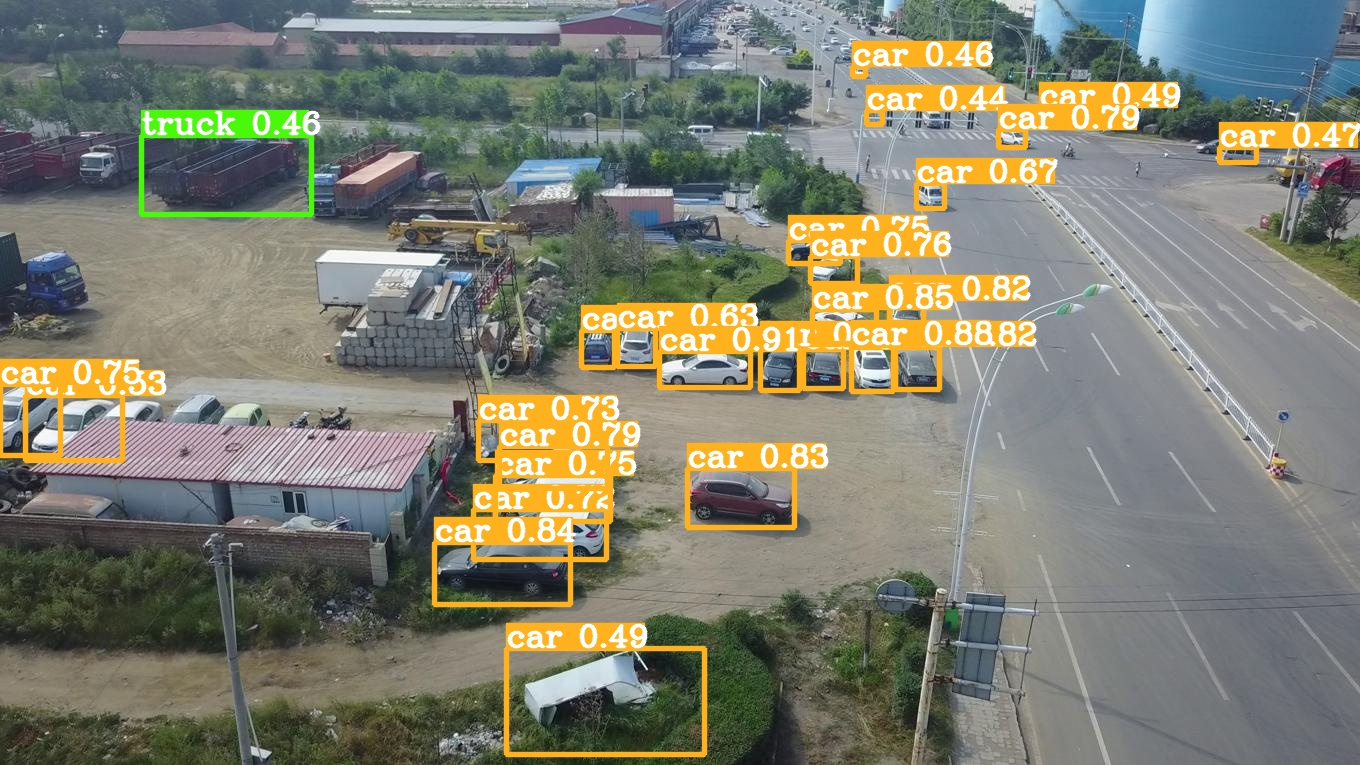

In [14]:
import os
import glob
from IPython.display import Image, display

# Find all test-dev images
test_img_dir = f"{WORKING_ROOT}/images/test-dev"
test_images = sorted(glob.glob(os.path.join(test_img_dir, "*.jpg")))

if test_images:
    sample_img = os.path.realpath(test_images[0])
    print(f"Running inference on: {sample_img}")
    
    # Resolve best weights
    best_weights = globals().get('BEST_WEIGHTS', f"runs/train/gold_yolo_visdrone_{MODEL_SIZE}/weights/best_ckpt.pt")
    
    # Run the inference command
    !python tools/infer.py \
        --weights {best_weights} \
        --yaml data/visdrone.yaml \
        --source {sample_img} \
        --device {DEVICES.split(',')[0] if DEVICES else 'cpu'} \
        --project runs/inference_previews \
        --name sample_prediction
        
    # Find the output image
    out_images = glob.glob("runs/inference_previews/sample_prediction/*.jpg")
    if out_images:
        print(f"Displaying results from: {out_images[0]}")
        display(Image(filename=out_images[0]))
    else:
        print("Inference completed, but output image not found.")
else:
    print("No test-dev images found for inference.")

## 14. Save results (Kaggle Output)
Download **`gold_yolo_visdrone_results.zip`** from the **Output** tab after the run.

In [15]:
import glob
import json
import os
import shutil
from pathlib import Path

current_exp_name = f"gold_yolo_visdrone_{MODEL_SIZE}"

results_root = Path("/kaggle/working/gold_yolo_results")
(results_root / "weights").mkdir(parents=True, exist_ok=True)
(results_root / "metrics").mkdir(parents=True, exist_ok=True)
(results_root / "predictions").mkdir(parents=True, exist_ok=True)
(results_root / "batch_previews").mkdir(parents=True, exist_ok=True)
(results_root / "inference_previews").mkdir(parents=True, exist_ok=True)

# Best weights
src_weights = Path(f"runs/train/{current_exp_name}/weights/best_ckpt.pt")
if src_weights.exists():
    shutil.copy2(src_weights, results_root / "weights" / f"{current_exp_name}_best.pt")
    print(f"Copied weights to {results_root / 'weights'}")
else:
    print("No best_ckpt.pt found")

# Batch previews (from smoke/full training)
for img in glob.glob(f"runs/train/gold_yolo_visdrone*/train_batch*.jpg"):
    shutil.copy2(img, results_root / "batch_previews" / Path(img).name)
print(f"Copied batch previews to {results_root / 'batch_previews'}")

# Phase 1 metrics
phase1_eval_dir = sorted(glob.glob(f"runs/val/*{current_exp_name}_phase1*"), key=os.path.getmtime, reverse=True)
if phase1_eval_dir:
    metrics_src = Path(phase1_eval_dir[0]) / "evaluate_results.json"
    if metrics_src.exists():
        shutil.copy2(metrics_src, results_root / "metrics" / "phase1_coco_eval.json")
        print(f"Copied phase1 metrics")

# Phase 1 predictions
pred_src = sorted(glob.glob(f"runs/val/*{current_exp_name}_phase1*/predictions.json"), key=os.path.getmtime, reverse=True)
if pred_src:
    shutil.copy2(pred_src[0], results_root / "predictions" / "phase1_coco_results.json")
    print(f"Copied phase1 predictions")

# Phase 2 SAHI metrics (result.json contains predictions in COCO format)
sahi_results = sorted(glob.glob("runs/sahi_eval/**/result.json", recursive=True), key=os.path.getmtime, reverse=True)
if sahi_results:
    shutil.copy2(sahi_results[0], results_root / "metrics" / "phase2_sahi_eval.json")
    print(f"Copied phase2 SAHI results")

# Inference previews
for img in glob.glob("runs/inference_previews/sample_prediction/*.jpg"):
    shutil.copy2(img, results_root / "inference_previews" / Path(img).name)
print(f"Copied inference previews to {results_root / 'inference_previews'}")

zip_path = "/kaggle/working/gold_yolo_visdrone_results"
shutil.make_archive(zip_path, "zip", str(results_root))
print(f"Zipped results to {zip_path}.zip")

Copied weights to /kaggle/working/gold_yolo_results/weights
Copied batch previews to /kaggle/working/gold_yolo_results/batch_previews
Copied phase2 SAHI results
Copied inference previews to /kaggle/working/gold_yolo_results/inference_previews
Zipped results to /kaggle/working/gold_yolo_visdrone_results.zip


## 15. Final summary (read this when you return)

In [16]:
import glob
import json
from datetime import datetime, timezone
from pathlib import Path

def resolve_best_weights(exp_name=f"gold_yolo_visdrone_{MODEL_SIZE}"):
    p = Path(f"runs/train/{exp_name}/weights/best_ckpt.pt")
    return str(p) if p.is_file() else None

summary = {
    "status": "complete",
    "finished_utc": datetime.now(timezone.utc).isoformat(),
    "visdrone_root": VISDRONE_ROOT,
    "working_root": WORKING_ROOT,
    "repo": REPO_ROOT,
    "best_weights": resolve_best_weights(),
    "results_zip": "/kaggle/working/gold_yolo_visdrone_results.zip",
    "results_folder": "/kaggle/working/gold_yolo_results",
    "phase1_eval_dirs": sorted(glob.glob(f"runs/val/*gold_yolo_phase1*")),
    "sahi_result_jsons": sorted(
        glob.glob("runs/sahi_eval/**/result.json", recursive=True),
        key=os.path.getmtime,
        reverse=True,
    ),
    "train_log_dirs": sorted(glob.glob(f"runs/train/gold_yolo_visdrone_{MODEL_SIZE}*")),
}

summary_path = "/kaggle/working/pipeline_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("=" * 60)
print("PIPELINE FINISHED — check these when you return")
print("=" * 60)
for k, v in summary.items():
    print(f"  {k}: {v}")
print()
print("Download from Kaggle Output tab:")
print("  ", summary["results_zip"])
print("  ", summary_path)
print("=" * 60)

PIPELINE FINISHED — check these when you return
  status: complete
  finished_utc: 2026-06-11T09:43:52.423653+00:00
  visdrone_root: /kaggle/input/datasets/imranbhuiyan999/visdrone-datase/Dataset1
  working_root: /kaggle/working/VisDrone-DET
  repo: /kaggle/working/Efficient-Computing/Detection/Gold-YOLO
  best_weights: runs/train/gold_yolo_visdrone_s/weights/best_ckpt.pt
  results_zip: /kaggle/working/gold_yolo_visdrone_results.zip
  results_folder: /kaggle/working/gold_yolo_results
  phase1_eval_dirs: []
  sahi_result_jsons: ['runs/sahi_eval/exp/result.json']
  train_log_dirs: ['runs/train/gold_yolo_visdrone_s']

Download from Kaggle Output tab:
   /kaggle/working/gold_yolo_visdrone_results.zip
   /kaggle/working/pipeline_summary.json
